# Breast Cancer Classification

## Problem Definition
Predicting whether a breast tumor is malignant or benign based on measurements computed from digitized images of a fine needle aspirate.

- Learning type: Supervised Learning
- Problem type: Binary Classification
- Algorithm: Support Vector Machine (SVM)
- Target: target (0 = Malignant, 1 = Benign)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_breast_cancer

RANDOM_STATE = 42

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Shape:", df.shape)
print("Target names:", dict(enumerate(data.target_names)))

Shape: (569, 31)
Target names: {0: np.str_('malignant'), 1: np.str_('benign')}


In [3]:
raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

raw_path = raw_dir / "breast_cancer.csv"
df.to_csv(raw_path, index=False)

print("Saved to:", raw_path)

Saved to: ..\data\raw\breast_cancer.csv


In [4]:
df = pd.read_csv(raw_path)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
print("Shape:", df.shape)
print()
df.info()

Shape: (569, 31)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error   

In [6]:
print("Missing values:", df.isna().sum().sum())
print("Duplicated rows:", df.duplicated().sum())

Missing values: 0
Duplicated rows: 0


In [7]:
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(4))

target
1    357
0    212
Name: count, dtype: int64

target
1    0.6274
0    0.3726
Name: proportion, dtype: float64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


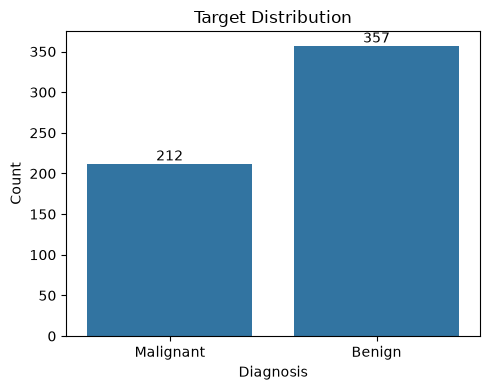

In [9]:
labels = {0: "Malignant", 1: "Benign"}

plt.figure(figsize=(5, 4))
ax = sns.countplot(x=df["target"].map(labels), order=["Malignant", "Benign"])
for container in ax.containers:
    ax.bar_label(container)
plt.title("Target Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [10]:
corr_target = (
    df.corr()["target"]
    .drop("target")
    .sort_values()
)

print(corr_target.round(4).to_string())

worst concave points      -0.7936
worst perimeter           -0.7829
mean concave points       -0.7766
worst radius              -0.7765
mean perimeter            -0.7426
worst area                -0.7338
mean radius               -0.7300
mean area                 -0.7090
mean concavity            -0.6964
worst concavity           -0.6596
mean compactness          -0.5965
worst compactness         -0.5910
radius error              -0.5671
perimeter error           -0.5561
area error                -0.5482
worst texture             -0.4569
worst smoothness          -0.4215
worst symmetry            -0.4163
mean texture              -0.4152
concave points error      -0.4080
mean smoothness           -0.3586
mean symmetry             -0.3305
worst fractal dimension   -0.3239
compactness error         -0.2930
concavity error           -0.2537
fractal dimension error   -0.0780
symmetry error             0.0065
texture error              0.0083
mean fractal dimension     0.0128
smoothness err

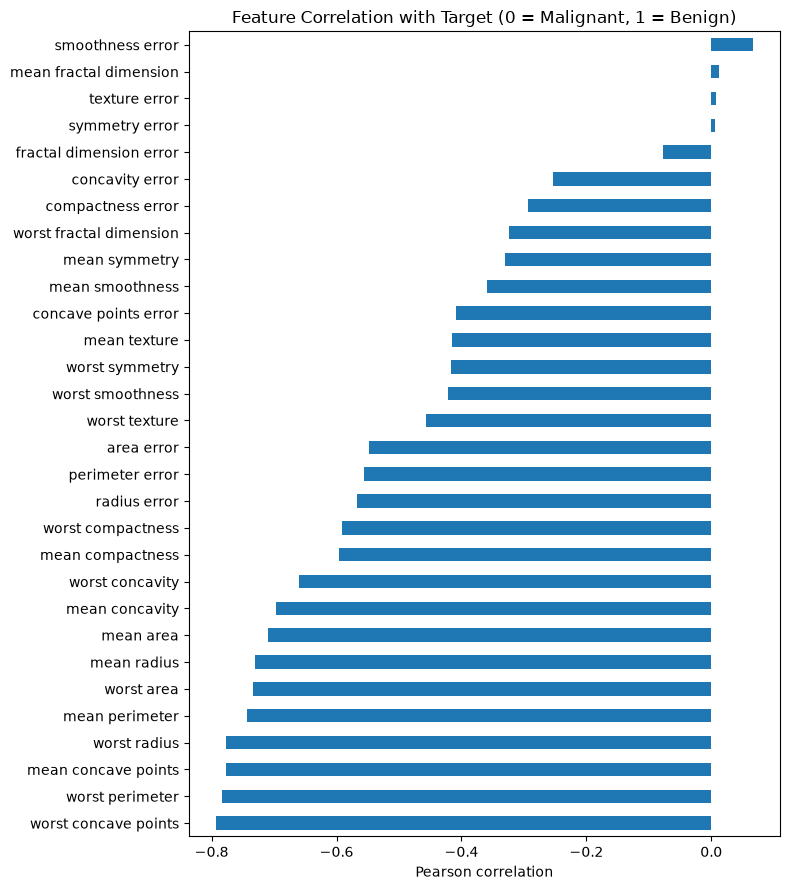

In [11]:
plt.figure(figsize=(8, 9))
corr_target.plot(kind="barh")
plt.title("Feature Correlation with Target (0 = Malignant, 1 = Benign)")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

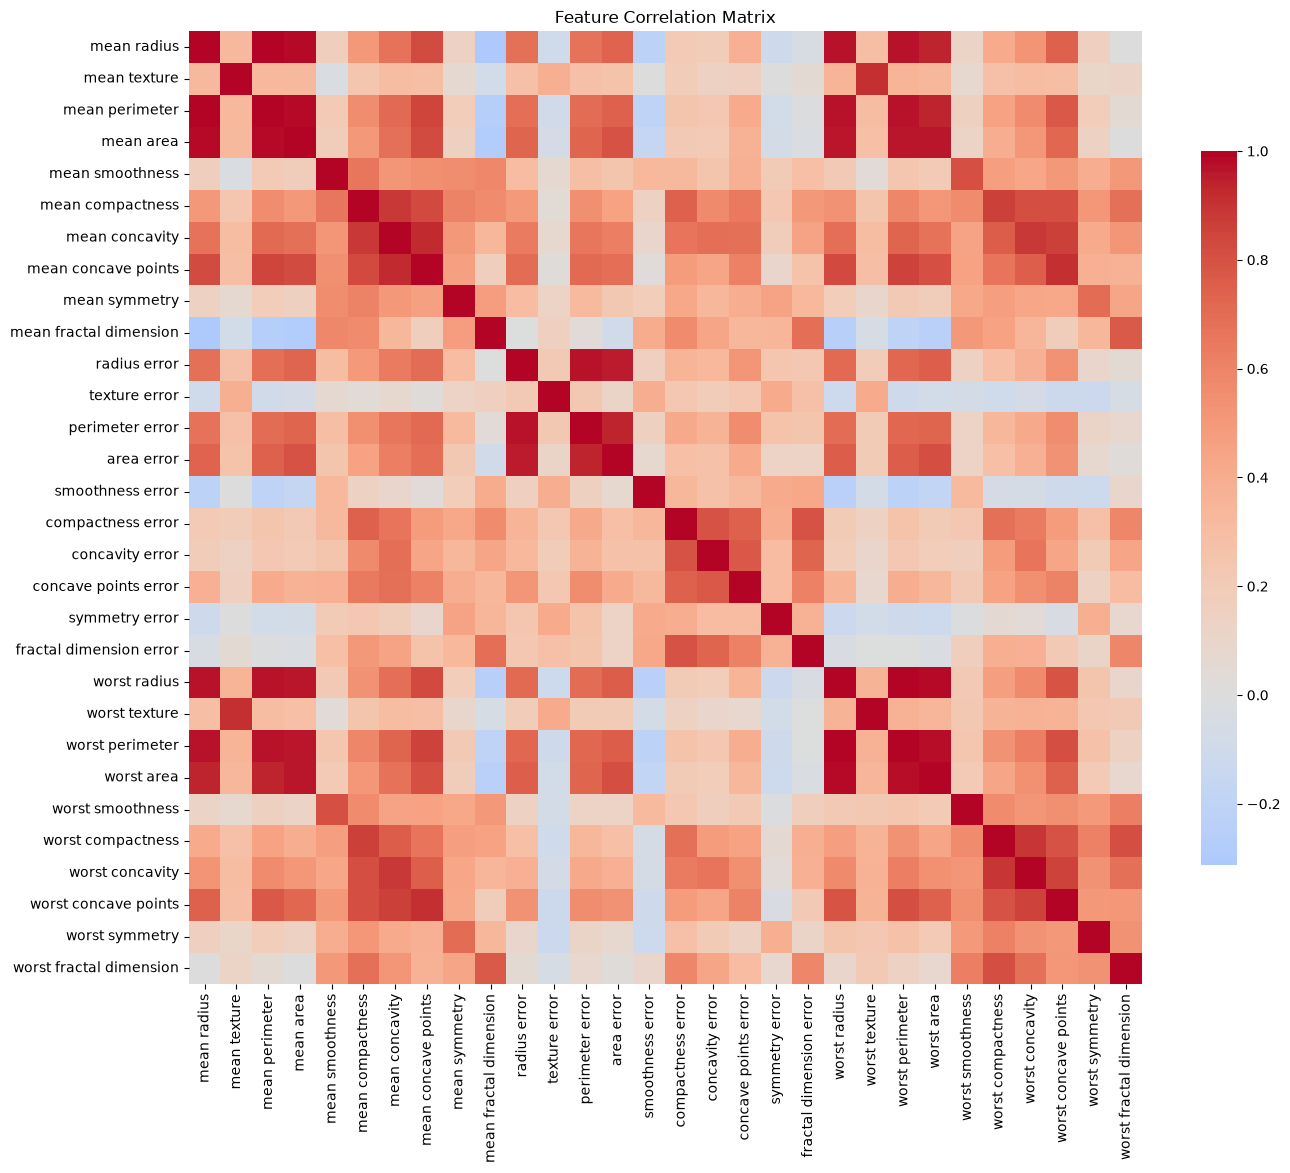

In [12]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    df.drop(columns="target").corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
corr_matrix = df.drop(columns="target").corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))

pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .rename("abs_corr")
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "abs_corr"]

print("Pairs with |corr| > 0.9:", (pairs["abs_corr"] > 0.9).sum())
print()
print(pairs.head(10).round(4).to_string(index=False))

Pairs with |corr| > 0.9: 21

      feature_1       feature_2  abs_corr
    mean radius  mean perimeter    0.9979
   worst radius worst perimeter    0.9937
    mean radius       mean area    0.9874
 mean perimeter       mean area    0.9865
   worst radius      worst area    0.9840
worst perimeter      worst area    0.9776
   radius error perimeter error    0.9728
 mean perimeter worst perimeter    0.9704
    mean radius    worst radius    0.9695
 mean perimeter    worst radius    0.9695


Top features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius']


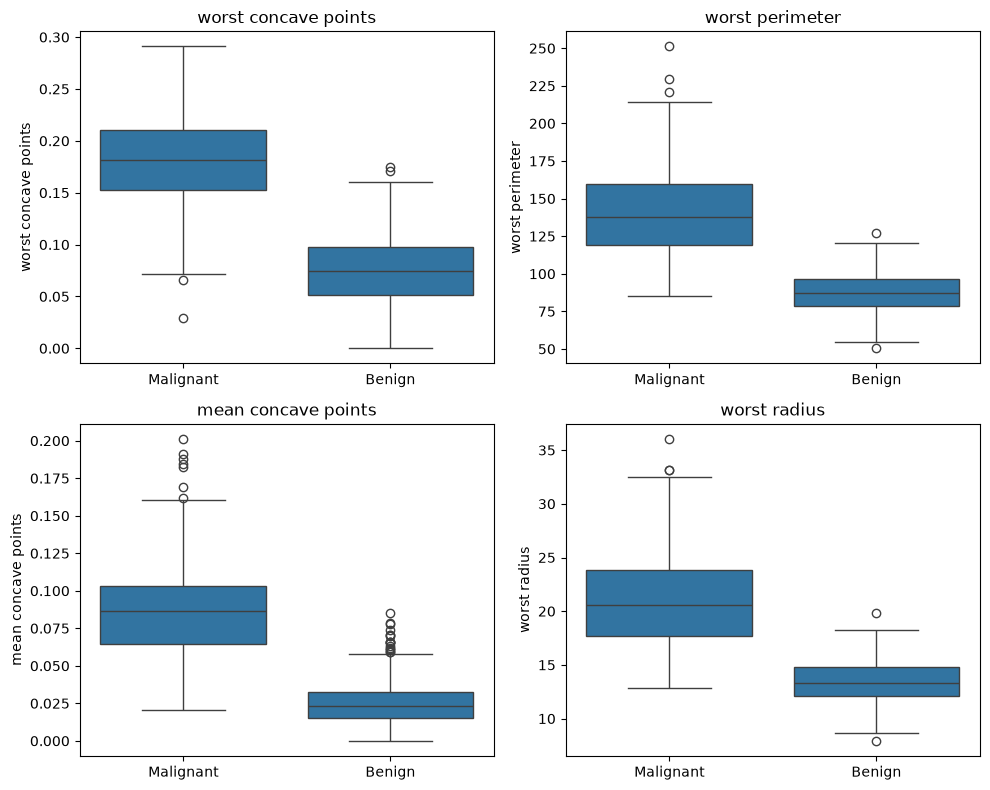

In [14]:
top_features = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
print("Top features:", top_features)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.ravel(), top_features):
    sns.boxplot(x=df["target"].map(labels), y=df[feature], order=["Malignant", "Benign"], ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [15]:
print(df.groupby(df["target"].map(labels))[top_features].mean().round(4).T.to_string())

target                 Benign  Malignant
worst concave points   0.0744     0.1822
worst perimeter       87.0059   141.3703
mean concave points    0.0257     0.0880
worst radius          13.3798    21.1348


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print()
print("Train target distribution:")
print(y_train.value_counts())
print()
print("Test target distribution:")
print(y_test.value_counts())

X_train: (455, 30)
X_test: (114, 30)

Train target distribution:
target
1    285
0    170
Name: count, dtype: int64

Test target distribution:
target
1    72
0    42
Name: count, dtype: int64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
}

kernels = {
    "Linear": SVC(kernel="linear", random_state=RANDOM_STATE),
    "RBF": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Polynomial (degree 3)": SVC(kernel="poly", degree=3, random_state=RANDOM_STATE),
}

rows = []
for name, clf in kernels.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("svm", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    row = {"Model": name}
    for metric in scoring:
        scores = res[f"test_{metric}"]
        row[metric] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    rows.append(row)

baseline_df = pd.DataFrame(rows).set_index("Model")
baseline_df

,accuracy,recall_macro,f1_macro,roc_auc
Model,,,,
Linear,0.9648 ± 0.0162,0.9612 ± 0.0200,0.9623 ± 0.0176,0.9947 ± 0.0073
RBF,0.9692 ± 0.0146,0.9659 ± 0.0189,0.9669 ± 0.0160,0.9956 ± 0.0048
Polynomial (degree 3),0.8967 ± 0.0330,0.8618 ± 0.0442,0.8805 ± 0.0408,0.9940 ± 0.0035


In [18]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC(random_state=RANDOM_STATE))])

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", 0.01, 0.1],
    },
]

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="recall_macro",
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV recall_macro:", round(grid.best_score_, 4))

Best params: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV recall_macro: 0.9712


In [19]:
results = pd.DataFrame(grid.cv_results_)
top = (
    results[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)
top["params"] = top["params"].astype(str)
print(top.round(4).to_string(index=False))

                                                    params  mean_test_score  std_test_score  rank_test_score
  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}           0.9712          0.0207                1
                  {'svm__C': 0.1, 'svm__kernel': 'linear'}           0.9700          0.0152                2
{'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}           0.9641          0.0155                3
   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}           0.9641          0.0185                3
 {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}           0.9630          0.0271                5
                   {'svm__C': 10, 'svm__kernel': 'linear'}           0.9624          0.0243                6
                 {'svm__C': 0.01, 'svm__kernel': 'linear'}           0.9618          0.0150                7
                    {'svm__C': 1, 'svm__kernel': 'linear'}           0.9612          0.0200                8
 {'svm__C': 100, 's

In [20]:
best_rbf = results[results["param_svm__kernel"] == "rbf"].sort_values("rank_test_score").iloc[0]
best_lin = results[results["param_svm__kernel"] == "linear"].sort_values("rank_test_score").iloc[0]

compare = pd.DataFrame({
    "Model": ["RBF (best)", "Linear (best)"],
    "Params": [str(best_rbf["params"]), str(best_lin["params"])],
    "Mean recall_macro": [best_rbf["mean_test_score"], best_lin["mean_test_score"]],
    "Std": [best_rbf["std_test_score"], best_lin["std_test_score"]],
})
print(compare.round(4).to_string(index=False))
print()
print("Final model (grid.best_estimator_):")
print(grid.best_estimator_)

        Model                                                   Params  Mean recall_macro    Std
   RBF (best) {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}             0.9712 0.0207
Linear (best)                 {'svm__C': 0.1, 'svm__kernel': 'linear'}             0.9700 0.0152

Final model (grid.best_estimator_):
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, gamma=0.01, random_state=42))])


In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

final_model = grid.best_estimator_

y_pred = final_model.predict(X_test)
scores = final_model.decision_function(X_test)


def compute_metrics(y_true, y_pred, scores):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Malignant precision": precision_score(y_true, y_pred, pos_label=0),
        "Malignant recall": recall_score(y_true, y_pred, pos_label=0),
        "Malignant F1": f1_score(y_true, y_pred, pos_label=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "ROC-AUC": roc_auc_score(y_true, scores),
    }


test_metrics = compute_metrics(y_test, y_pred, scores)
for name, value in test_metrics.items():
    print(f"{name}: {value:.4f}")

print()
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[0, 1]),
    index=["True Malignant", "True Benign"],
    columns=["Pred Malignant", "Pred Benign"],
)
print(cm)

print()
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"], digits=4))

Accuracy: 0.9825
Malignant precision: 0.9762
Malignant recall: 0.9762
Malignant F1: 0.9762
Recall (macro): 0.9812
ROC-AUC: 0.9977

                Pred Malignant  Pred Benign
True Malignant              41            1
True Benign                  1           71

              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



In [22]:
rng = np.random.RandomState(RANDOM_STATE)

y_true_arr = y_test.to_numpy()
y_pred_arr = np.asarray(y_pred)
scores_arr = np.asarray(scores)
n = len(y_true_arr)

boot = {name: [] for name in test_metrics}
for _ in range(1000):
    idx = rng.randint(0, n, n)
    if len(np.unique(y_true_arr[idx])) < 2:
        continue
    m = compute_metrics(y_true_arr[idx], y_pred_arr[idx], scores_arr[idx])
    for name, value in m.items():
        boot[name].append(value)

ci_rows = []
for name, values in boot.items():
    low, high = np.percentile(values, [2.5, 97.5])
    ci_rows.append({
        "Metric": name,
        "Test score": round(test_metrics[name], 4),
        "95% CI": f"[{low:.4f}, {high:.4f}]",
    })

print("Valid resamples:", len(boot["Accuracy"]))
print(pd.DataFrame(ci_rows).to_string(index=False))

Valid resamples: 1000
             Metric  Test score           95% CI
           Accuracy      0.9825 [0.9561, 1.0000]
Malignant precision      0.9762 [0.9200, 1.0000]
   Malignant recall      0.9762 [0.9189, 1.0000]
       Malignant F1      0.9762 [0.9362, 1.0000]
     Recall (macro)      0.9812 [0.9490, 1.0000]
            ROC-AUC      0.9977 [0.9910, 1.0000]


In [23]:
errors = X_test.copy()
errors["true"] = y_test.map(labels)
errors["pred"] = pd.Series(y_pred, index=X_test.index).map(labels)
errors["decision_score"] = scores
errors["error_type"] = np.where(
    (y_test == 0) & (y_pred == 1), "False Negative (malignant missed)",
    np.where((y_test == 1) & (y_pred == 0), "False Positive (benign flagged)", "Correct")
)

wrong = errors[errors["error_type"] != "Correct"]
print(wrong[["true", "pred", "decision_score", "error_type"]].round(4).to_string())

print()
print("Decision score summary (all test samples):")
print(errors.groupby("true")["decision_score"].describe().round(4).to_string())

          true       pred  decision_score                         error_type
541     Benign  Malignant         -0.2879    False Positive (benign flagged)
73   Malignant     Benign          0.9144  False Negative (malignant missed)

Decision score summary (all test samples):
           count    mean     std     min     25%     50%     75%     max
true                                                                    
Benign      72.0  2.0646  1.0878 -0.2879  1.1746  1.9725  2.8916  4.6178
Malignant   42.0 -2.9260  1.4881 -5.5392 -3.9145 -3.1142 -1.9435  0.9144


In [24]:
tp_malignant = errors[(y_test == 0) & (y_pred == 0)]
tn_benign = errors[(y_test == 1) & (y_pred == 1)]
fn = errors[errors["error_type"].str.startswith("False Negative")]

feature_cols = X_test.columns.tolist()

comparison = pd.DataFrame({
    "FN (missed malignant)": fn[feature_cols].mean(),
    "True malignant (caught)": tp_malignant[feature_cols].mean(),
    "True benign": tn_benign[feature_cols].mean(),
})

# how close the FN is to benign vs malignant, in units of the gap between class means
gap = comparison["True benign"] - comparison["True malignant (caught)"]
comparison["FN position (0=malignant, 1=benign)"] = (
    (comparison["FN (missed malignant)"] - comparison["True malignant (caught)"]) / gap
)

top_gap = comparison.loc[top_features]
print("Top 4 features:")
print(top_gap.round(4).to_string())

print()
print("Share of all 30 features where FN is closer to benign mean than malignant mean:")
closer_to_benign = (comparison["FN position (0=malignant, 1=benign)"] > 0.5).sum()
print(f"{closer_to_benign} / {len(comparison)}")

Top 4 features:
                      FN (missed malignant)  True malignant (caught)  True benign  FN position (0=malignant, 1=benign)
worst concave points                 0.1383                   0.1808       0.0805                               0.4235
worst perimeter                    110.3000                 146.7395      88.4085                               0.6247
mean concave points                  0.0507                   0.0905       0.0287                               0.6443
worst radius                        16.5700                  21.9417      13.5793                               0.6424

Share of all 30 features where FN is closer to benign mean than malignant mean:
22 / 30


In [25]:
for margin in [0.5, 1.0]:
    in_zone = errors[errors["decision_score"].abs() < margin]
    print(f"|score| < {margin}: {len(in_zone)} samples, "
          f"{(in_zone['error_type'] != 'Correct').sum()} errors")

print()
zone = errors[errors["decision_score"].abs() < 1.0]
print(zone[["true", "pred", "decision_score", "error_type"]].round(4).sort_values("decision_score").to_string())

|score| < 0.5: 7 samples, 1 errors
|score| < 1.0: 16 samples, 2 errors

          true       pred  decision_score                         error_type
385  Malignant  Malignant         -0.7794                            Correct
461  Malignant  Malignant         -0.6744                            Correct
194  Malignant  Malignant         -0.6648                            Correct
41   Malignant  Malignant         -0.4035                            Correct
205  Malignant  Malignant         -0.3388                            Correct
541     Benign  Malignant         -0.2879    False Positive (benign flagged)
291     Benign     Benign          0.0537                            Correct
526     Benign     Benign          0.1038                            Correct
542     Benign     Benign          0.1243                            Correct
363     Benign     Benign          0.1300                            Correct
340     Benign     Benign          0.5597                            Correct
204 

In [26]:
from sklearn.model_selection import cross_val_predict

oof_scores = cross_val_predict(
    grid.best_estimator_, X_train, y_train, cv=cv, method="decision_function"
)
oof_pred = (oof_scores > 0).astype(int)
oof_wrong = oof_pred != y_train.to_numpy()

print("Train OOF errors:", oof_wrong.sum(), "/", len(y_train))
print()

rows = []
for margin in [0.5, 0.75, 1.0, 1.25]:
    in_zone_tr = np.abs(oof_scores) < margin
    in_zone_te = np.abs(scores) < margin
    test_wrong = (np.asarray(y_pred) != y_test.to_numpy())
    rows.append({
        "margin": margin,
        "train zone size": int(in_zone_tr.sum()),
        "train errors in zone": int((oof_wrong & in_zone_tr).sum()),
        "train errors outside": int((oof_wrong & ~in_zone_tr).sum()),
        "test zone size": int(in_zone_te.sum()),
        "test errors in zone": int((test_wrong & in_zone_te).sum()),
        "test errors outside": int((test_wrong & ~in_zone_te).sum()),
    })

print(pd.DataFrame(rows).to_string(index=False))

Train OOF errors: 11 / 455

 margin  train zone size  train errors in zone  train errors outside  test zone size  test errors in zone  test errors outside
   0.50               26                     8                     3               7                    1                    1
   0.75               42                    10                     1              10                    1                    1
   1.00               56                    10                     1              16                    2                    0
   1.25               80                    10                     1              28                    2                    0


In [27]:
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "breast_cancer_svm_pipeline.pkl"
joblib.dump(final_model, model_path)

loaded_model = joblib.load(model_path)

same_pred = np.array_equal(loaded_model.predict(X_test), final_model.predict(X_test))
same_scores = np.allclose(loaded_model.decision_function(X_test), final_model.decision_function(X_test))

print("Saved to:", model_path)
print("Identical predictions:", same_pred)
print("Identical decision scores:", same_scores)

Saved to: ..\models\breast_cancer_svm_pipeline.pkl
Identical predictions: True
Identical decision scores: True


In [28]:
import json

UNCERTAINTY_MARGIN = 0.75  # chosen from train out-of-fold scores only

app_meta = {
    "feature_defaults": X_train.median().round(6).to_dict(),
    "uncertainty_margin": UNCERTAINTY_MARGIN,
}

meta_path = models_dir / "app_meta.json"
with open(meta_path, "w") as f:
    json.dump(app_meta, f, indent=2)

print("Saved to:", meta_path)
print("Number of default features:", len(app_meta["feature_defaults"]))
print("Uncertainty margin:", app_meta["uncertainty_margin"])

Saved to: ..\models\app_meta.json
Number of default features: 30
Uncertainty margin: 0.75
